# HW3 - Part 2

## 3.3: Gaussian State Preparation

In the following exercise we are going to implement circuits that prepare a gaussian state. Gaussian functions are fundamental for various quantum algorithms and applications, such as financial modeling, thermal state preparation and more. 

By preparing a gaussian state we look for a quantum circuit with effective unitary $U$ which fulfills:

$U |0\rangle = \sum_x {\sqrt{f(x)}|x\rangle}$ 

where $f(x)$ is a normalized gaussian, such that $\sum_x{f(x)}=1$.

Since we live in a discrete and finite space, we should choose a specific grid and truncation for our gaussian. We set $f(x) = \frac{e^{-0.5x^2}}{Z}$ ($Z$ is a normalization factor) as the wanted gaussian, with a grid $x \in[-4, 4)$ (the number of points in the grid is determined by `NUM_QUBITS`).

To make it clear, we plot the wanted discretization of the probability distribution:

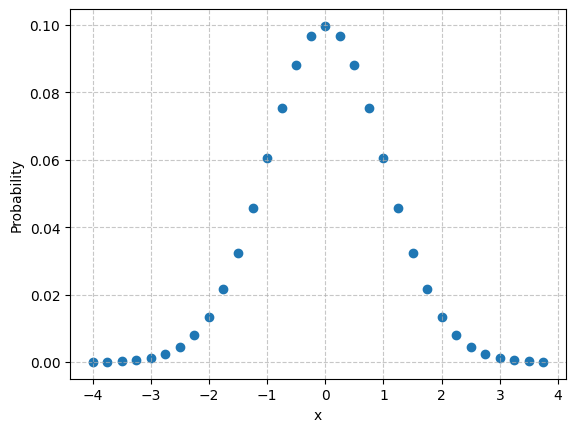

In [1]:
import numpy as np
import matplotlib.pyplot as plt

NUM_QUBITS = 5

FRACTION_DIGITS = NUM_QUBITS - 3 # Because we want the grid [-4, 4). 
EXP_RATE = 1/2

grid = np.linspace(-4, 4 - 8 / (2**NUM_QUBITS), 2**(NUM_QUBITS))

wanted_gaussian = np.exp(- EXP_RATE * grid**2)
wanted_gaussian /= np.sum(wanted_gaussian)  # Normalize the Gaussian

plt.scatter(grid, wanted_gaussian)
plt.xlabel('x')
plt.ylabel('Probability')
plt.grid(True, linestyle='--', alpha=0.7)

### Part A: load the gaussian using the `prepare_state` function

Using the `prepare_state` function, load the wanted gaussian state. Note that `x` is defined to be a signed integer (encoded with [2's-complement encoding](https://en.wikipedia.org/wiki/Two%27s_complement)).

In [ ]:
@qfunc
def prepare_gaussian_funcion_direct(x: QNum):
    # your code here
    pass

@qfunc
def main(x: Output[QNum[NUM_QUBITS, SIGNED, FRACTION_DIGITS]]):
    allocate(x)
    # Prepare Gaussian state
    prepare_gaussian_funcion_direct(x)


# Generate the quantum model with constraints
qmod = create_model(main,
                    execution_preferences=ExecutionPreferences(num_shots=1000000),
                    constraints=Constraints(max_width=25))

# Synthesize the quantum program
qprog = synthesize(qmod)
res = execute(qprog).get_sample_result()

# show information about the synthesized circuit
circuit = QuantumProgram.from_qprog(qprog)
print("depth:", circuit.transpiled_circuit.depth, "width:", circuit.data.width)
print("counts:", circuit.transpiled_circuit.count_ops)

In [3]:
def verify_results(parsed_counts, num_qubits):
    EXP_RATE = 1/2
    
    grid = np.linspace(-4, 4 - 8 / (2**NUM_QUBITS), 2**(NUM_QUBITS))
    
    wanted_gaussian = np.exp(- EXP_RATE * grid**2)
    wanted_gaussian /= np.sum(wanted_gaussian)  # Normalize the Gaussian

    x = [sample.state['x'] for sample in parsed_counts]
    probs = np.array([sample.shots for sample in parsed_counts])
    probs = probs/probs.sum()
    
    plt.scatter(grid, wanted_gaussian, color='blue',label = "wanted")
    plt.scatter(x, probs, color='red', marker='+', label = "sampled")
    plt.xlabel('x')
    plt.ylabel('Probability')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

#verify_results(res.parsed_counts, NUM_QUBITS)

### Part B: load the gaussian using amplitude loading

The first method we used is non-scalable, and we will build towards an efficient implementation. The approach is taken from another Grover's algorithm, termed ["black box state preparation"](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.85.1334).

The idea is to start with a uniform distribution over the state, and use amplitude loading to load a wanted probability function $f(x)$:
$$
\frac{1}{N}\sum_x{|x\rangle}|0\rangle_{ind} \rightarrow \frac{1}{N}\sum_x{|x\rangle(f(x)|1\rangle_{ind} + \sqrt{1-f^2(x)}|0\rangle}_{ind})
$$
Then post select\amplify the indicator qubit to get the desired distribution.

**Task:** using amplitude loading (i.e [`*=` \ `assign_amplitude`](https://docs.classiq.io/latest/qmod-reference/language-reference/statements/amplitude-encoding-assignment/)), load the desired gaussian. Now you will have an additional indicator qubit. Make sure to post-select it correctly in the post processing to verify you got the actual distribution.

In [ ]:
from classiq.qmod.symbolic import exp #import symbolic functions from here for the usage in `*=`


@qfunc
def prepare_gaussian_funcion_amplitude_loading(x: QNum, ind: QBit):
    # your code here
    pass

@qfunc
def main(x: Output[QNum[NUM_QUBITS, SIGNED, FRACTION_DIGITS]], ind: Output[QBit]):
    allocate(x)
    allocate(ind)
    
    # Prepare Gaussian state
    prepare_gaussian_funcion_amplitude_loading(x, ind)


# Generate the quantum model with constraints
qmod = create_model(main,
                    execution_preferences=ExecutionPreferences(num_shots=1000000),
                    constraints=Constraints(max_width=25))

# Synthesize the quantum program
qprog = synthesize(qmod)
res = execute(qprog).get_sample_result()

parsed_counts = [sample for sample in res.parsed_counts if sample.state['ind']] # post select for ind=1
verify_results(parsed_counts, NUM_QUBITS)

### Part C: a scalable implementation!

This part is **optional**. Completing it will guarantee some points in the *creativity* category.

So the previous part was still non-scalable, as the general amplitude function has exponential cost in the number of qubits. We now leverage both digital and analog quantum transformations to implement the same transformation as in part B. The idea is, given a state $|x\rangle$, to calculate $|x\rangle|x^2\rangle$. Then implement amplitude loading of a gaussian state in order to get $|x\rangle|x^2\rangle(e^{-0.5x^2}|00...0\rangle + ...)$.

**Task**: First think how to efficiently implement amplitude loading of an exponent using the same number of indicator qubits as the number input qubits (hint: think about decomposition of the exponent according to the binary representation).

In [ ]:
@qfunc
def exponential_amplitude_loading(exp_rate: CReal, y: QArray[QBit], ind: QArray[QBit]):
    # your code here
    pass

Now use this primitive and digital transformation in order to load the gaussian state, as done in part B:

In [ ]:
@qfunc
def prepare_gaussian_funcion_scalable(x: QNum[NUM_QUBITS, SIGNED, FRACTION_DIGITS], ind: QArray):
    # your code here
    pass

@qfunc
def main(x: Output[QNum[NUM_QUBITS, SIGNED, FRACTION_DIGITS]], ind: Output[QArray]):
    allocate(x)
    allocate(2*x.size-1, ind) # use indicators in the same size as x**2
    
    # Prepare Gaussian state
    prepare_gaussian_funcion_scalable(x, ind)


# Generate the quantum model with constraints
qmod = create_model(main,
                    execution_preferences=ExecutionPreferences(num_shots=1000000),
                    constraints=Constraints(max_width=25))

# Synthesize the quantum program
qprog = synthesize(qmod)
res = execute(qprog).get_sample_result()

parsed_counts = [sample for sample in res.parsed_counts if np.sum(sample.state['ind']) == 0] # post select for ind=0,0,0,..,0
verify_results(parsed_counts, NUM_QUBITS)